In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles
from scipy.optimize import minimize
from scipy.special import expit, logit

import warnings
warnings.filterwarnings("ignore")

import self_training as st


# Analysis of Self-Training in Simple Logistic Regression

In [96]:
cfg = st.SelfTrainingConfig(
    N=100, M=10000, N_test=10000, d=500, 
    mu_plus=0.1*np.ones(500), mu_minus=-0.1*np.ones(500), 
    p=0.9, T=10, n_runs=20, n_jobs=10, seed=0, 
    sigma_scale=2.0
)

rng = np.random.default_rng(cfg.seed)
X_lab, Y_lab = st.sample_data(cfg.N, cfg, rng)
X_unl, _     = st.sample_data(cfg.M, cfg, rng)
X_test, Y_test = st.sample_data(cfg.N_test, cfg, rng)

T = 50

In [ ]:
def res_logistic_regression_N(cfg, runs, seeds, penalty, C, total, T, p, N_list):
    length = len(N_list)
    res = np.zeros((length, runs, T+1))

    for i in range(length):
        for j in range(runs):
            
            seed = seeds[j]
            rng = np.random.default_rng(seed)
            X, Y = st.sample_data(total, cfg, rng)
            X_test, Y_test = st.sample_data(cfg.N_test, cfg, rng)
        
            N = N_list[i]
            X_lab, Y_lab = X[:N], Y[:N]
            X_unl = X[N:]

            res[i, j] = st.run_self_training(p, T, X_lab, Y_lab, X_unl, X_test, Y_test, penalty=penalty, C=C)
            
    return res

def plot_logistic_regression_N(res, runs, penalty, C, total, T, p, N_list):
    length = len(N_list)
    cmap = plt.colormaps['plasma'] 
    fig, axes = plt.subplots(1, length, figsize=(15, 4), sharey=True)
    for i in range(length):
        N = N_list[i]

        results = res[i]
        
        mean_trajectory = np.mean(results, axis=0)
        median_trajectory = np.median(results, axis=0)
        lower_bound = np.percentile(results, 10, axis=0) # 10th percentile
        upper_bound = np.percentile(results, 90, axis=0)

        color_index = i / length
        line_color = cmap(color_index)

        axes[i].plot(np.arange(T+1), median_trajectory, color=line_color, 
                     linewidth=1.0, label=f"N={N}, $\lambda$={(total-N)/N:.2f}")
        
        axes[i].plot(np.arange(T+1), mean_trajectory, color=line_color, 
                     linewidth=1.0, linestyle='--', alpha=0.8)
                     
        axes[i].fill_between(np.arange(T+1), 
                lower_bound, 
                upper_bound, 
                color=line_color, alpha=0.2)
        
        axes[i].grid()
        axes[i].legend()
        axes[i].set_xlabel(r"Iterations")

    axes[0].set_ylabel(r"Error")
    fig.suptitle(f"Test Error of Self-Training with $N+M={total}$, $p={p}$, penalty={penalty}, $C={C}$, averaged over {runs} runs")
    plt.show()

In [119]:
def res_logistic_regression_p(cfg, runs, seeds, penalty, C, total, T, N, p_list):
    length = len(p_list)
    res = np.zeros((length, runs, T+1))

    for i in range(length):
        for j in range(runs):
            
            seed = seeds[j]
            rng = np.random.default_rng(seed)
            X, Y = st.sample_data(total, cfg, rng)
            X_test, Y_test = st.sample_data(cfg.N_test, cfg, rng)
        
            p = p_list[i]
            X_lab, Y_lab = X[:N], Y[:N]
            X_unl = X[N:]

            res[i, j] = st.run_self_training(p, T, X_lab, Y_lab, X_unl, X_test, Y_test, penalty=penalty, C=C)
    
    return res

def plot_logistic_regression_p(res, runs, penalty, C, total, T, N, p_list):
    length = len(p_list)
    cmap = plt.colormaps['plasma'] 
    fig, axes = plt.subplots(1, length, figsize=(15, 4), sharey=True)
    for i in range(length):
        p = p_list[i]

        results = res[i]

        mean_trajectory = np.mean(results, axis=0)
        median_trajectory = np.median(results, axis=0)
        lower_bound = np.percentile(results, 10, axis=0) # 10th percentile
        upper_bound = np.percentile(results, 90, axis=0)

        color_index = i / length
        line_color = cmap(color_index)

        axes[i].plot(np.arange(T+1), median_trajectory, color=line_color, 
                     linewidth=1.0, label=f"p={p}")
        
        axes[i].plot(np.arange(T+1), mean_trajectory, color=line_color, 
                     linewidth=1.0, linestyle='--', alpha=0.8)
                     
        axes[i].fill_between(np.arange(T+1), 
                lower_bound, 
                upper_bound, 
                color=line_color, alpha=0.2)
        
        axes[i].grid()
        axes[i].legend()
        axes[i].set_xlabel(r"Iterations")

    axes[0].set_ylabel(r"Error")
    fig.suptitle(f"Test Error of Self-Training with $N={total}$, $M={total-N}$, $p={p}$, penalty={penalty}, $C={C}$, averaged over {runs} runs")
    plt.show()

In [120]:
runs = 10
seeds = range(runs)
total = 10000

## No Regularization

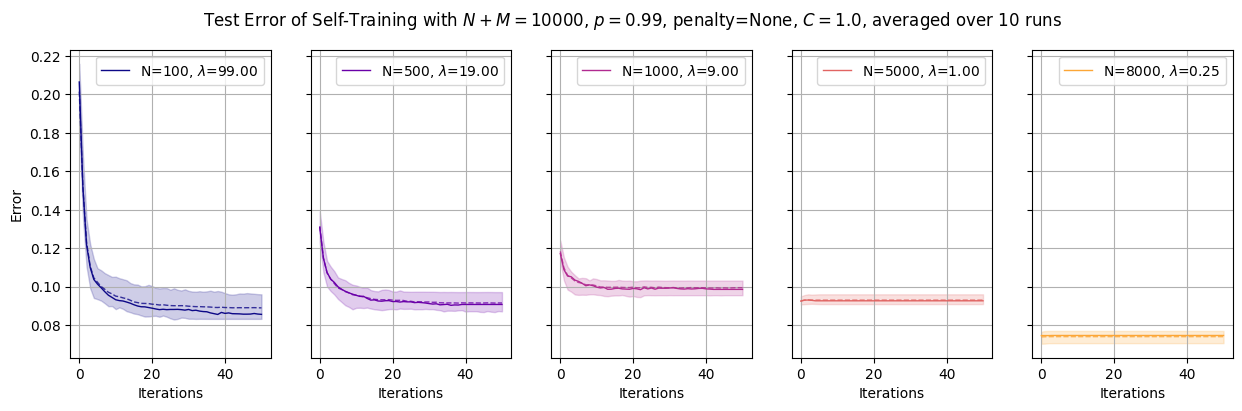

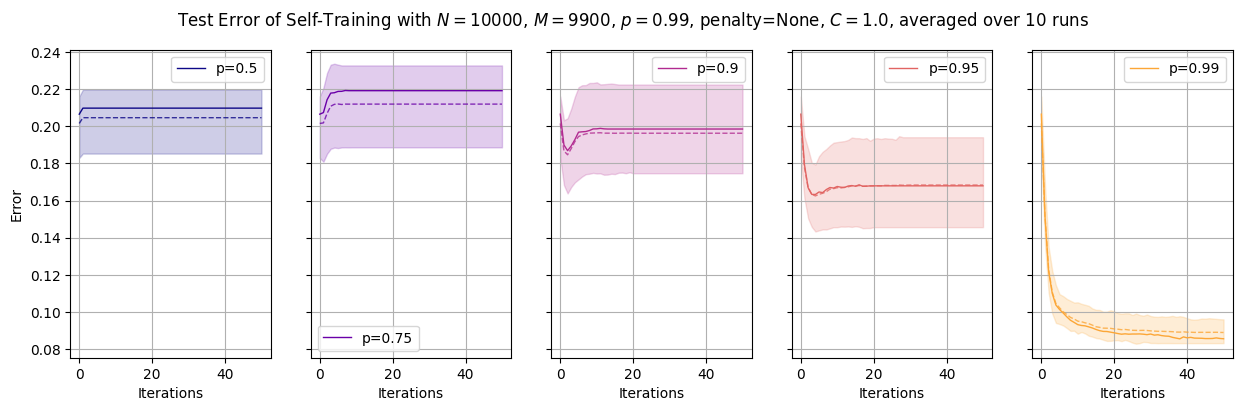

In [121]:
penalty = None
C = 1.0

# Varying N
p = 0.99
N_list = [100, 500, 1000, 5000, 8000]

N_res = res_logistic_regression_N(cfg, runs, seeds, penalty, C, total, T, p, N_list)
plot_logistic_regression_N(N_res, runs, penalty, C, total, T, p, N_list)

# Varying p
N = 100
p_list = [0.5, 0.75, 0.9, 0.95, 0.99]

p_res = res_logistic_regression_p(cfg, runs, seeds, penalty, C, total, T, N, p_list)
plot_logistic_regression_p(p_res, runs, penalty, C, total, T, N, p_list)

## $L^2$ Regularization

$$C = 1/ \lambda$$

$$ C \ell(Y X^\top \beta) + \tfrac12 \| \beta\|^2_2 $$

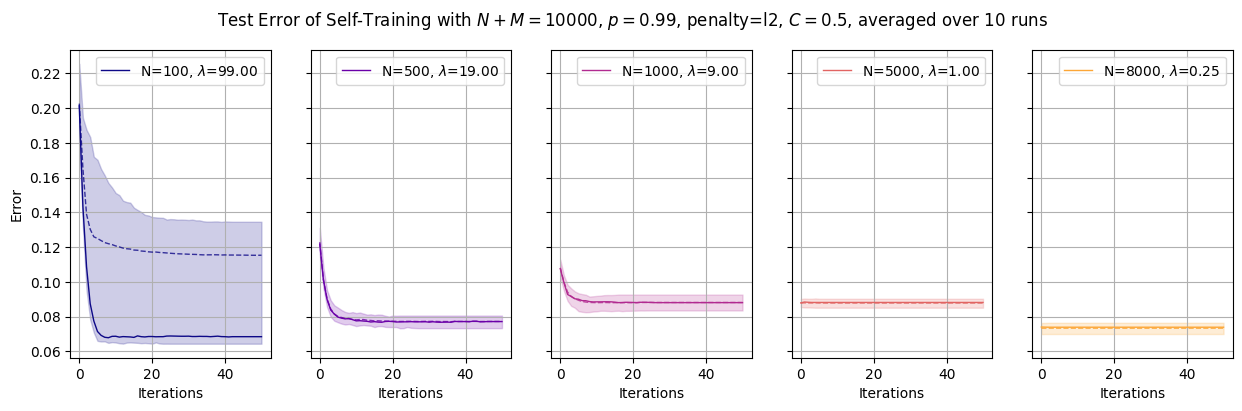

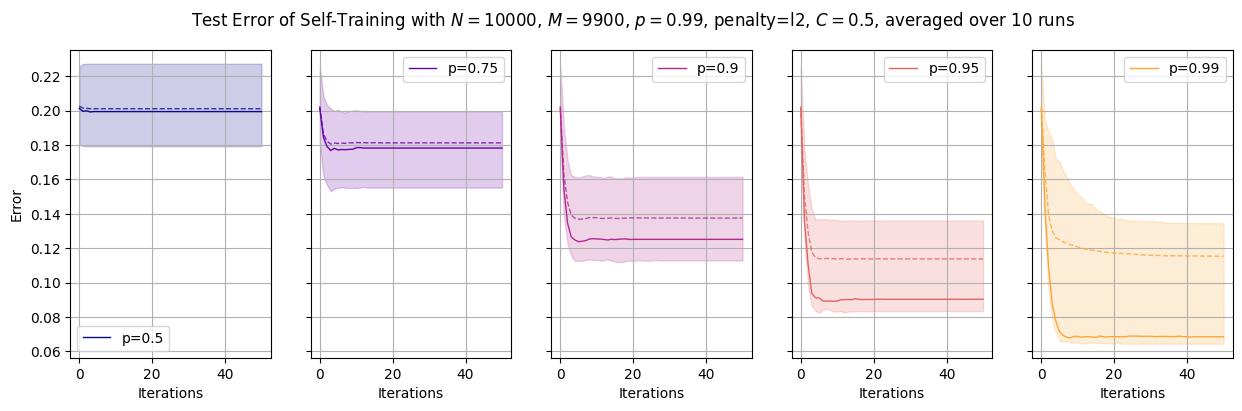

In [126]:
penalty = 'l2'
C = 0.5

# Varying N
p = 0.99
N_list = [100, 500, 1000, 5000, 8000]

N_res = res_logistic_regression_N(cfg, runs, seeds, penalty, C, total, T, p, N_list)
plot_logistic_regression_N(N_res, runs, penalty, C, total, T, p, N_list)

# Varying p
N = 100
p_list = [0.5, 0.75, 0.9, 0.95, 0.99]

p_res = res_logistic_regression_p(cfg, runs, seeds, penalty, C, total, T, N, p_list)
plot_logistic_regression_p(p_res, runs, penalty, C, total, T, N, p_list)

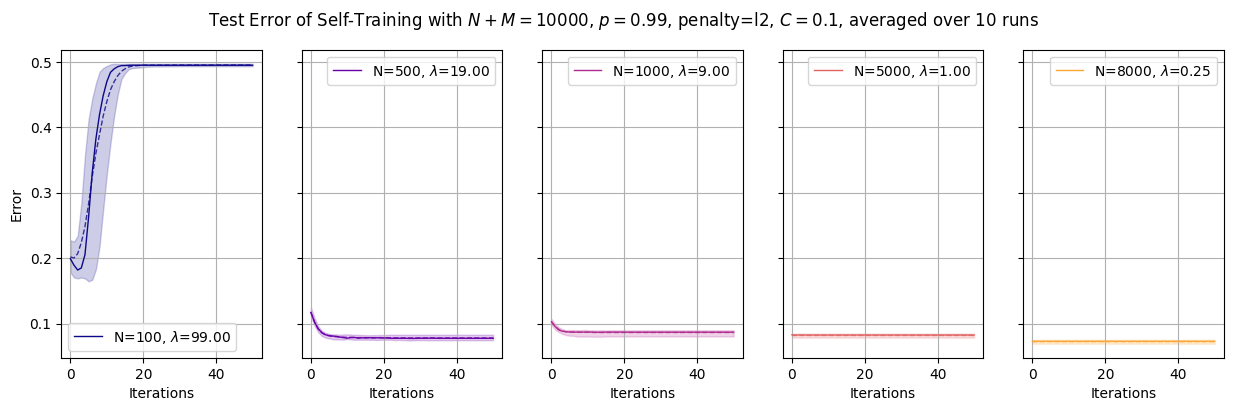

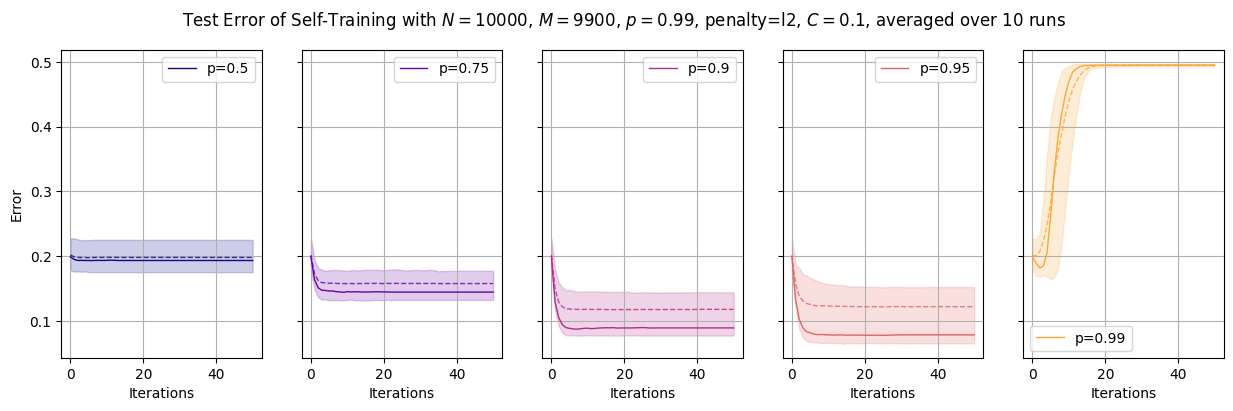

In [124]:
penalty = 'l2'
C = 0.1

# Varying N
p = 0.99
N_list = [100, 500, 1000, 5000, 8000]

N_res = res_logistic_regression_N(cfg, runs, seeds, penalty, C, total, T, p, N_list)
plot_logistic_regression_N(N_res, runs, penalty, C, total, T, p, N_list)

# Varying p
N = 100
p_list = [0.5, 0.75, 0.9, 0.95, 0.99]

p_res = res_logistic_regression_p(cfg, runs, seeds, penalty, C, total, T, N, p_list)
plot_logistic_regression_p(p_res, runs, penalty, C, total, T, N, p_list)

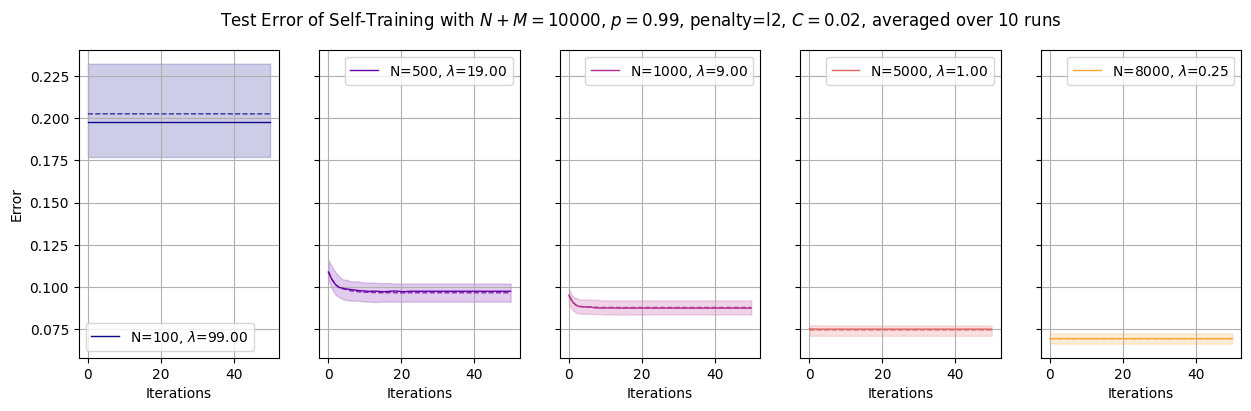

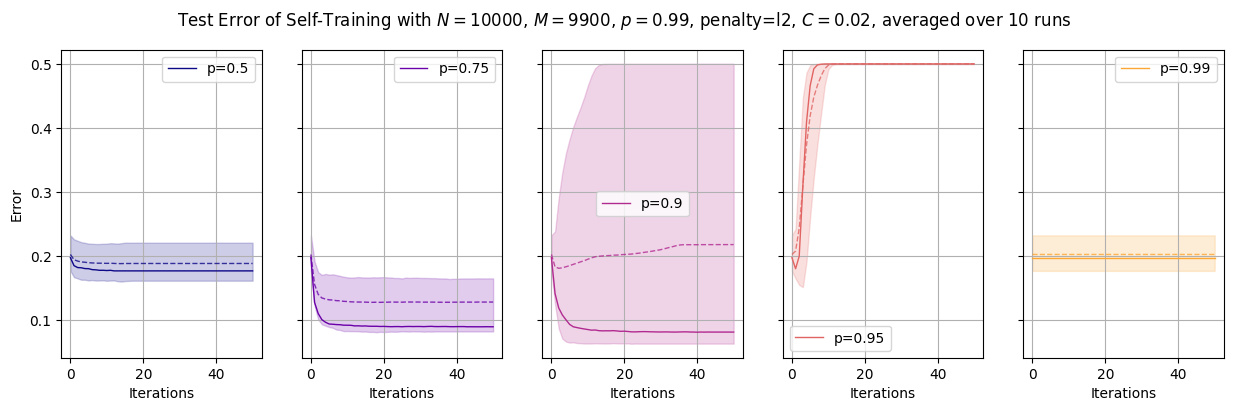

In [125]:
penalty = 'l2'
C = 0.02

# Varying N
p = 0.99
N_list = [100, 500, 1000, 5000, 8000]

N_res = res_logistic_regression_N(cfg, runs, seeds, penalty, C, total, T, p, N_list)
plot_logistic_regression_N(N_res, runs, penalty, C, total, T, p, N_list)

# Varying p
N = 100
p_list = [0.5, 0.75, 0.9, 0.95, 0.99]

p_res = res_logistic_regression_p(cfg, runs, seeds, penalty, C, total, T, N, p_list)
plot_logistic_regression_p(p_res, runs, penalty, C, total, T, N, p_list)

# Analysis of Self-Training in Series Logistic Regression and Series Density Estimation (Legendre Polynomials)

In [ ]:
class PrecomputedAdditiveLegendre:
    def __init__(self, X_global: np.ndarray, K_max: int, quad_deg: int = 200):
        """
        Precomputes the complete basis design matrices for the entire dataset 
        and the quadrature nodes required for numerical integration.
        """
        self.K_max = K_max
        self.d = X_global.shape[1] if X_global.ndim > 1 else 1
        
        # 1. Determine scaling bounds to map all features into [-1, 1]
        self.x_min = np.min(X_global, axis=0)
        self.x_max = np.max(X_global, axis=0)
        self.scale = self.x_max - self.x_min
        self.scale[self.scale == 0] = 1.0 # Prevent division by zero
        
        # 2. Quadrature setup for integration over [-1, 1]
        nodes_1d, weights_1d = np.polynomial.legendre.leggauss(quad_deg)
        self.nodes_1d = nodes_1d
        self.weights_1d = weights_1d
        
        # 3. Precompute Global Data Matrix \Psi_global
        self.Psi_global = self._build_additive_psi(X_global)
        
        # 4. Precompute Nodes Matrix \Psi_nodes & \Lambda
        # Since we use an additive model over d dimensions, the integral splits:
        # \int \sum L_k(x^{(j)}) dx = d \int L_k(x) dx (assuming independent uniform measure)
        self.Psi_nodes = self._build_1d_psi(self.nodes_1d) * self.d
        self.Lambda_global = self.Psi_nodes.T @ self.weights_1d

    def _build_1d_psi(self, x_1d: np.ndarray) -> np.ndarray:
        """Helper: Builds 1D Legendre basis."""
        Psi = np.zeros((x_1d.shape[0], self.K_max))
        for k in range(self.K_max):
            coef = np.zeros(k + 1)
            coef[k] = 1.0
            Psi[:, k] = np.polynomial.legendre.legval(x_1d, coef)
        return Psi

    def _build_additive_psi(self, X: np.ndarray) -> np.ndarray:
        """Helper: Builds Additive Legendre basis across d dimensions."""
        X_scaled = 2.0 * (X - self.x_min) / self.scale - 1.0
        if self.d == 1:
            return self._build_1d_psi(X_scaled.squeeze())
            
        N = X.shape[0]
        Psi = np.zeros((N, self.K_max))
        for k in range(self.K_max):
            coef = np.zeros(k + 1)
            coef[k] = 1.0
            # Evaluate polynomial on each dimension and sum (Additive Model)
            evaluated = np.polynomial.legendre.legval(X_scaled, coef)
            Psi[:, k] = np.sum(evaluated, axis=1)
        return Psi


# Series Logistic Regression

def fit_logistic_offset(Psi: np.ndarray, Y: np.ndarray, offset: np.ndarray, 
                        l2_reg: float = 1e-4) -> np.ndarray:
    """Solves for \vartheta minimizing the empirical logistic loss with an offset."""
    N = Psi.shape[0]
    
    def objective(vartheta):
        logits = Psi @ vartheta + offset
        loss = np.mean(np.logaddexp(0, -Y * logits))
        return loss + 0.5 * l2_reg * np.sum(vartheta**2)
        
    def gradient(vartheta):
        logits = Psi @ vartheta + offset
        grad = -Psi.T @ (Y * (1 - expit(Y * logits))) / N
        return grad + l2_reg * vartheta

    res = minimize(objective, np.zeros(Psi.shape[1]), jac=gradient, method='L-BFGS-B')
    return res.x

def run_series_logistic_regression(X_L0: np.ndarray, Y_L0: np.ndarray, 
                                   X_U0: np.ndarray, X_test: np.ndarray, Y_test: np.ndarray,
                                   kappa: float, T: int, K_seq: list, l2_reg: float = 1e-4) -> np.ndarray:
    """
    Returns an array of shape (T+1,) containing the test error at each round.
    """
    N, M = X_L0.shape[0], X_U0.shape[0]
    K_max = K_seq[-1]
    
    # 1. Global Precomputation
    X_global = np.vstack([X_L0, X_U0])
    basis = PrecomputedAdditiveLegendre(X_global, K_max)
    Psi_global = basis.Psi_global
    
    # Precompute Test Matrix (using scaling bounds from training data)
    Psi_test = basis._build_additive_psi(X_test)
    
    idx_L0 = np.arange(N)
    idx_U0 = np.arange(N, N + M)
    
    # Initialization t = 0
    K_0 = K_seq[0]
    Psi_L0_J0 = Psi_global[idx_L0, :K_0]
    theta_current = fit_logistic_offset(Psi_L0_J0, Y_L0, np.zeros(N), l2_reg)
    
    # Track Error at t=0
    Y_pred_0 = np.sign(Psi_test[:, :K_0] @ theta_current)
    Y_pred_0[Y_pred_0 == 0] = 1  # Handle exact 0 logits
    errors = [np.mean(Y_pred_0 != Y_test)]
    
    for t in range(T):
        K_prev = K_seq[t]
        K_next = K_seq[t+1]
        
        # 1. Evaluate current function on U0
        h_U0 = Psi_global[idx_U0, :K_prev] @ theta_current
        
        # 2. Pseudo-labeling
        mask = np.abs(h_U0) >= kappa
        
        if mask.sum() > 0:
            idx_pseudo = idx_U0[mask]
            Y_pseudo = np.sign(h_U0[mask])
            # Construct \mathcal{L}_{t+1} (L0 U Pseudo)
            idx_Lt1 = np.concatenate([idx_L0, idx_pseudo])
            Y_Lt1 = np.concatenate([Y_L0, Y_pseudo])
        else:
            # If no new points, still fit next basis block on L0 to reduce approximation error
            idx_Lt1 = np.copy(idx_L0)
            Y_Lt1 = np.copy(Y_L0)
        
        # 3. Slicing for I_t (the new basis columns)
        Psi_Lt1_I = Psi_global[idx_Lt1, K_prev:K_next]
        
        # 4. Compute Offset h_{t-1}(X)
        offset_Lt1 = Psi_global[idx_Lt1, :K_prev] @ theta_current
        
        # 5. Fit new block \vartheta_{t+1}
        vartheta = fit_logistic_offset(Psi_Lt1_I, Y_Lt1, offset_Lt1, l2_reg)
        
        # 6. Concatenate \theta_{t+1}
        theta_current = np.concatenate([theta_current, vartheta])
        
        # 7. Evaluate Error for round t+1
        Y_pred_t1 = np.sign(Psi_test[:, :K_next] @ theta_current)
        Y_pred_t1[Y_pred_t1 == 0] = 1
        errors.append(np.mean(Y_pred_t1 != Y_test))
        
    return np.array(errors)


# Series Log-density Estimation

def solve_density_update(Psi_data: np.ndarray, Psi_nodes: np.ndarray, 
                         base_h_nodes: np.ndarray, Lambda_I: np.ndarray, 
                         weights: np.ndarray) -> np.ndarray:
    """
    Implements the Solve() operator with analytical Jacobians.
    """
    N = Psi_data.shape[0]
    if N == 0:
        return np.zeros(Psi_data.shape[1])
        
    def objective(vartheta):
        h_nodes = base_h_nodes + Psi_nodes @ vartheta
        max_h = np.max(h_nodes)
        
        # log \int \exp(h(y)) dy via log-sum-exp
        E = np.exp(h_nodes - max_h)
        Z = np.sum(weights * E)
        psi_J = max_h + np.log(Z)
        
        empirical_mean = np.mean(Psi_data @ vartheta)
        return -(empirical_mean - psi_J)
        
    def gradient(vartheta):
        h_nodes = base_h_nodes + Psi_nodes @ vartheta
        max_h = np.max(h_nodes)
        
        E = np.exp(h_nodes - max_h)
        Z = np.sum(weights * E)
        
        # Analytical gradient
        expected_Psi = (Psi_nodes.T @ (weights * E)) / Z
        empirical_Psi = np.mean(Psi_data, axis=0)
        return -(empirical_Psi - expected_Psi)

    # Strict linear constraint: \Lambda_I^\top \vartheta = 0
    constraints = [{
        'type': 'eq', 
        'fun': lambda v: Lambda_I @ v, 
        'jac': lambda v: Lambda_I
    }]
    
    res = minimize(objective, np.zeros(Psi_data.shape[1]), jac=gradient, 
                   method='SLSQP', constraints=constraints, options={'maxiter': 500})
    return res.x


def run_series_log_density(X_L0: np.ndarray, Y_L0: np.ndarray, 
                           X_U0: np.ndarray, X_test: np.ndarray, Y_test: np.ndarray,
                           pi: float, kappa: float, T: int, K_seq: list) -> np.ndarray:
    """
    Returns an array of shape (T+1,) containing the test error at each round.
    """
    N, M = X_L0.shape[0], X_U0.shape[0]
    K_max = K_seq[-1]
    
    # 1. Global Precomputation
    X_global = np.vstack([X_L0, X_U0])
    basis = PrecomputedAdditiveLegendre(X_global, K_max)
    
    Psi_global = basis.Psi_global
    Psi_nodes = basis.Psi_nodes
    weights = basis.weights_1d
    Lambda_global = basis.Lambda_global
    
    Psi_test = basis._build_additive_psi(X_test)
    
    idx_L0_plus = np.where(Y_L0 == 1)[0]
    idx_L0_minus = np.where(Y_L0 == -1)[0]
    idx_U0 = np.arange(N, N + M)
    
    # Initialization t = 0
    K_0 = K_seq[0]
    theta_plus = solve_density_update(
        Psi_global[idx_L0_plus, :K_0], Psi_nodes[:, :K_0], np.zeros(len(weights)), 
        Lambda_global[:K_0], weights)
        
    theta_minus = solve_density_update(
        Psi_global[idx_L0_minus, :K_0], Psi_nodes[:, :K_0], np.zeros(len(weights)), 
        Lambda_global[:K_0], weights)
        
    def evaluate_test_error(t_plus, t_minus, K_current):
        P_nodes = Psi_nodes[:, :K_current]
        P_test = Psi_test[:, :K_current]
        
        Z_plus = np.sum(weights * np.exp(P_nodes @ t_plus))
        Z_minus = np.sum(weights * np.exp(P_nodes @ t_minus))
        
        log_odds = P_test @ (t_plus - t_minus) - np.log(Z_plus) + np.log(Z_minus) + np.log(pi / (1 - pi))
        preds = np.sign(log_odds)
        preds[preds == 0] = 1
        return np.mean(preds != Y_test)

    # Track Error at t=0
    errors = [evaluate_test_error(theta_plus, theta_minus, K_0)]

    def classifier_logits(idx_data, K_current, t_plus, t_minus):
        P_data = Psi_global[idx_data, :K_current]
        P_nodes = Psi_nodes[:, :K_current]
        
        Z_plus = np.sum(weights * np.exp(P_nodes @ t_plus))
        Z_minus = np.sum(weights * np.exp(P_nodes @ t_minus))
        
        log_odds = P_data @ (t_plus - t_minus) - np.log(Z_plus) + np.log(Z_minus) + np.log(pi / (1 - pi))
        return log_odds

    for t in range(T):
        K_prev = K_seq[t]
        K_next = K_seq[t+1]
        
        # 1. Pseudo-labeling
        c_U0 = classifier_logits(idx_U0, K_prev, theta_plus, theta_minus)
        mask = np.abs(c_U0) >= kappa
        
        if mask.sum() > 0:
            idx_pseudo_plus = idx_U0[mask][np.sign(c_U0[mask]) == 1]
            idx_pseudo_minus = idx_U0[mask][np.sign(c_U0[mask]) == -1]
            # Construct \mathcal{L}_{t+1}^\pm
            idx_Lt1_plus = np.concatenate([idx_L0_plus, idx_pseudo_plus])
            idx_Lt1_minus = np.concatenate([idx_L0_minus, idx_pseudo_minus])
        else:
            # Fallback to unaugmented dataset to expand basis
            idx_Lt1_plus = np.copy(idx_L0_plus)
            idx_Lt1_minus = np.copy(idx_L0_minus)
        
        # 3. Base functions for nodes
        base_h_nodes_plus = Psi_nodes[:, :K_prev] @ theta_plus
        base_h_nodes_minus = Psi_nodes[:, :K_prev] @ theta_minus
        
        # 4. Slicing for new block I_t
        Psi_I_nodes = Psi_nodes[:, K_prev:K_next]
        Lambda_I = Lambda_global[K_prev:K_next]
        
        # 5. Fit \vartheta_{t+1}^\pm
        vartheta_plus = solve_density_update(
            Psi_global[idx_Lt1_plus, K_prev:K_next], Psi_I_nodes, 
            base_h_nodes_plus, Lambda_I, weights)
            
        vartheta_minus = solve_density_update(
            Psi_global[idx_Lt1_minus, K_prev:K_next], Psi_I_nodes, 
            base_h_nodes_minus, Lambda_I, weights)
            
        # 6. Update parameters
        theta_plus = np.concatenate([theta_plus, vartheta_plus])
        theta_minus = np.concatenate([theta_minus, vartheta_minus])
        
        # 7. Evaluate Error for round t+1
        errors.append(evaluate_test_error(theta_plus, theta_minus, K_next))
        
    return np.array(errors)

In [91]:
def results(X_L0, Y_L0, X_U0, X_test, Y_test, pi, p, T, K_seq):
    kappa = logit(p)
    d = X_L0.shape[1]
    print(f"Parameters: d={d}, T={T}, p={p}")
    print(f"\n--- Series Logistic Regression ---")
    series_logistic_error = run_series_logistic_regression(
        X_L0=X_L0, Y_L0=Y_L0, X_U0=X_U0, X_test=X_test, Y_test=Y_test, kappa=kappa, T=T, K_seq=K_seq, l2_reg=1e-3
    )
    print(series_logistic_error)

    print(f"\n--- Series Log-density Estimation ---")
    series_density_error = run_series_log_density(
        X_L0=X_L0, Y_L0=Y_L0, X_U0=X_U0, X_test=X_test, Y_test=Y_test, pi=pi, kappa=kappa, T=T, K_seq=K_seq
    )
    print(series_density_error)

    print(f"\n--- Simple Logistic Regression ---")
    simple_logistic_error = st.run_self_training(
        p, T, X_lab=X_L0, Y_lab=Y_L0, X_unl=X_U0, X_test=X_test, Y_test=Y_test
    )
    print(simple_logistic_error)

In [92]:
N = 100
total = 10000
M = total - N
N_test = 5000
pi = 0.5 
T = 3
seed = 0
sigma_scale = 2.0

# Sieve Expansion Schedule: Define the number of basis functions K at each round t.
# For T=3 rounds, we need 4 values: [K_0, K_1, K_2, K_3].
# Here, we start with 3 basis functions and expand by 2 in each self-training round.
K_seq = [3, 5, 7, 9]

## Gaussian Mixture in High Dimensional Setting (d=500)

In [93]:
d = 500
p = 0.99
cfg = st.SelfTrainingConfig(
    N=N, M=M, N_test=N_test, d=d, 
    mu_plus=0.1 * np.ones(d), mu_minus=-0.1 * np.ones(d), 
    p=p, T=T, n_runs=1, n_jobs=1, seed=seed, 
    sigma_scale=sigma_scale
)

rng = np.random.default_rng(seed)
X, Y = st.sample_data(total, cfg, rng)
X_test, Y_test = st.sample_data(N_test, cfg, rng)
X_L0 = X[:N]
Y_L0 = Y[:N]
X_U0 = X[N:total]

results(X_L0, Y_L0, X_U0, X_test, Y_test, pi, p, T, K_seq)

Parameters: d=500, T=3, p=0.99

--- Series Logistic Regression ---
[0.0594 0.0584 0.0612 0.06  ]

--- Series Log-density Estimation ---
[0.0578 0.0592 0.0594 0.0608]

--- Simple Logistic Regression ---
[0.207  0.1464 0.1186 0.103 ]


## Gaussian Mixtures in Low Dimensional Setting (d=2)

Parameters: d=2, T=3, p=0.99

--- Series Logistic Regression ---
[0.1588 0.1578 0.1576 0.159 ]

--- Series Log-density Estimation ---
[0.159  0.1598 0.1654 0.1704]

--- Simple Logistic Regression ---
[0.1676 0.1698 0.1706 0.1702]


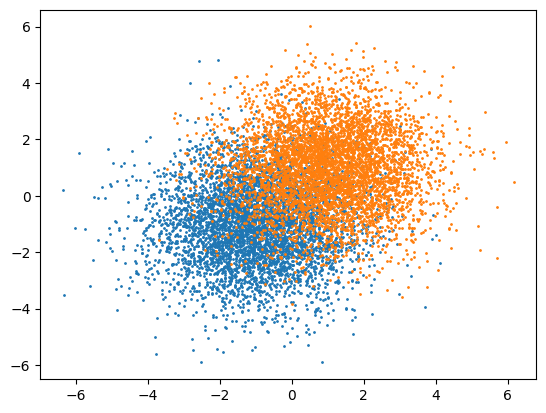

In [95]:
d = 2
p = 0.99
cfg = st.SelfTrainingConfig(
    N=N, M=M, N_test=N_test, d=d, 
    mu_plus= 1 * np.ones(d), mu_minus= -1 * np.ones(d), 
    p=p, T=T, n_runs=1, n_jobs=1, seed=seed, 
    sigma_scale=sigma_scale
)

rng = np.random.default_rng(seed)
X, Y = st.sample_data(total, cfg, rng)
X_test, Y_test = st.sample_data(N_test, cfg, rng)
X_L0 = X[:N]
Y_L0 = Y[:N]
X_U0 = X[N:total]

results(X_L0, Y_L0, X_U0, X_test, Y_test, pi, p, T, K_seq)

# Data Visualization
plt.scatter(X[Y==-1][:,0], X[Y==-1][:,1], s=1)
plt.scatter(X[Y==1][:,0], X[Y==1][:,1], s=1)
plt.show()

## Moons

Parameters: d=2, T=3, p=0.9

--- Series Logistic Regression ---
[0.4264 0.2982 0.3012 0.3406]

--- Series Log-density Estimation ---
[0.463  0.311  0.3104 0.279 ]

--- Simple Logistic Regression ---
[0.1266 0.127  0.1272 0.126 ]


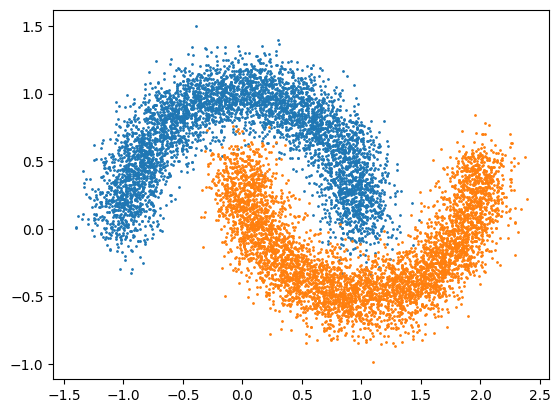

In [96]:
p = 0.9
X, Y = make_moons(n_samples=total, noise=np.sqrt(sigma_scale) * 0.1, 
                          random_state=seed)
X_test, Y_test = make_moons(n_samples=N_test, noise=np.sqrt(sigma_scale) * 0.1, 
                          random_state=seed)
Y = 2 * Y - 1
Y_test = 2 * Y_test - 1
X_L0 = X[:cfg.N]
Y_L0 = Y[:cfg.N]
X_U0 = X[cfg.N:cfg.N + cfg.M]

results(X_L0, Y_L0, X_U0, X_test, Y_test, pi, p, T, K_seq)

# Data Visualization
plt.scatter(X[Y==-1][:,0], X[Y==-1][:,1], s=1)
plt.scatter(X[Y==1][:,0], X[Y==1][:,1], s=1)
plt.show()

## Circles

Parameters: d=2, T=3, p=0.9

--- Series Logistic Regression ---
[0.0482 0.049  0.0486 0.047 ]

--- Series Log-density Estimation ---
[0.0636 0.0492 0.054  0.056 ]

--- Simple Logistic Regression ---
[0.5286 0.5286 0.5286 0.5286]


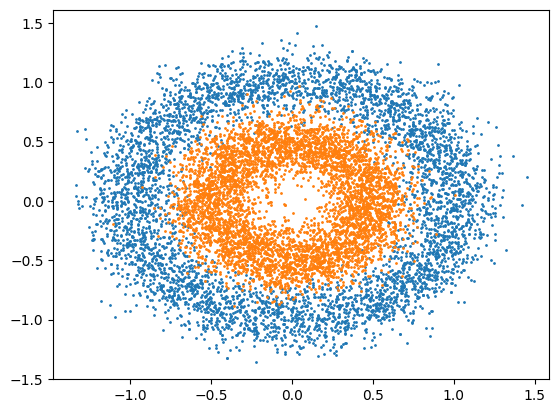

In [97]:
p = 0.9
X, Y = make_circles(n_samples=total, noise=np.sqrt(cfg.sigma_scale) * 0.1, 
                          random_state=cfg.seed, factor=0.5)
X_test, Y_test = make_circles(n_samples=cfg.N_test, noise=np.sqrt(cfg.sigma_scale) * 0.1, 
                          random_state=cfg.seed, factor=0.5)
Y = 2 * Y - 1
Y_test = 2 * Y_test - 1
X_L0 = X[:cfg.N]
Y_L0 = Y[:cfg.N]
X_U0 = X[cfg.N:cfg.N + cfg.M]

results(X_L0, Y_L0, X_U0, X_test, Y_test, pi, p, T, K_seq)

# Data Visualization
plt.scatter(X[Y==-1][:,0], X[Y==-1][:,1], s=1)
plt.scatter(X[Y==1][:,0], X[Y==1][:,1], s=1)
plt.show()